# Customer Churn Analysis

## Objective

The objective of this project is to analyze customer subscription data and identify
patterns associated with customer churn.

### Key Business Questions

1. What is the overall customer churn rate?
2. What is the estimated Customer Lifetime Value (CLV)?
3. How much Monthly Recurring Revenue (MRR) is at risk because of churn?
4. Which contract types have the highest churn?
5. Does customer tenure affect churn?
6. Which payment methods are associated with higher churn?
7. Do support tickets have any relationship with customer churn?
8. What actionable recommendations can help reduce customer churn?

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Import Required Libraries

We first import the Python libraries required for data loading, cleaning,
calculation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Customer Churn Dataset

The customer churn dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
file_path = r"C:\Users\DELL\Downloads\customer_churn_sample (2).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 15
Columns: 11


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,"1,919.76",One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,"5,399.64",Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


## 3. Dataset Overview

Before performing analysis, we inspect the structure of the dataset,
column names, data types, and sample records.

In [3]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# First five records
print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (15, 11)

Column Names:
['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod', 'Churn']

Data Types:
CustomerID              str
Gender                  str
Age                   int64
TenureMonths          int64
SubscriptionType        str
MonthlyCharges      float64
TotalCharges        float64
ContractType            str
SupportTickets        int64
PaymentMethod           str
Churn                   str
dtype: object

First 5 Records:


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,"1,919.76",One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,"5,399.64",Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


## 4. Data Quality Check

We check for:

- Missing values
- Duplicate records
- Incorrect data types
- Invalid churn values
- Negative financial values

This step ensures that the analysis is based on reliable data.

In [4]:
# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Unique values of important categorical columns
print("\nChurn Values:")
print(df["Churn"].unique())

print("\nContract Types:")
print(df["ContractType"].unique())

print("\nPayment Methods:")
print(df["PaymentMethod"].unique())

Missing Values:


CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64


Duplicate Rows: 0

Churn Values:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Contract Types:
<ArrowStringArray>
['Month-to-Month', 'One Year', 'Two Year']
Length: 3, dtype: str

Payment Methods:
<ArrowStringArray>
['Credit Card', 'Bank Transfer', 'UPI', 'Debit Card']
Length: 4, dtype: str


## 5. Data Cleaning

The following cleaning operations are performed:

- Remove duplicate records.
- Standardize categorical text.
- Convert numerical columns to numeric format.
- Remove invalid negative financial values if present.
- Validate the Churn column.

No unnecessary records are removed without a business reason.

In [5]:
# Create a copy
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Standardize categorical columns
categorical_columns = [
    "Gender",
    "SubscriptionType",
    "ContractType",
    "PaymentMethod",
    "Churn"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Convert numerical columns
numeric_columns = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Remove invalid financial values
df_clean = df_clean[
    (df_clean["MonthlyCharges"] >= 0) &
    (df_clean["TotalCharges"] >= 0)
]

# Reset index
df_clean.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())

Cleaned dataset shape: (15, 11)


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,"1,919.76",One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,"5,399.64",Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


## 6. Descriptive Statistics

Descriptive statistics help us understand customer demographics,
tenure, charges, and support-ticket behavior.

In [6]:
df_clean.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.00,15.00,15.00,15.00,15.00
mean,39.07,18.80,84.66,"2,088.48",2.53
std,11.39,14.33,42.74,"2,407.37",1.92
min,23.00,2.00,49.99,99.98,0.00
25%,30.00,7.00,49.99,449.91,1.00
50%,38.00,15.00,79.99,"1,099.78",2.00
75%,47.00,27.00,114.99,"3,209.73",4.00
max,60.00,48.00,149.99,"7,199.52",6.00


## 7. Baseline Churn Rate

Churn Rate measures the percentage of customers who have cancelled
their subscription.

### Formula

Churn Rate = (Number of Churned Customers / Total Customers) × 100

In [7]:
total_customers = len(df_clean)

churned_customers = (df_clean["Churn"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Churn Rate: {churn_rate:.2f}%")

Total Customers: 15
Churned Customers: 7
Churn Rate: 46.67%


## 8. Customer Retention Rate

Retention rate represents the percentage of customers who have remained
with the company.

### Formula

Retention Rate = 100% - Churn Rate

In [9]:
retention_rate = 100 - churn_rate

print(f"Retention Rate: {retention_rate:.2f}%")

Retention Rate: 53.33%


## 9. Customer Lifetime Value (CLV)

Customer Lifetime Value estimates the revenue generated by a customer
during their relationship with the company.

For this project, an estimated revenue-based CLV is calculated as:

Estimated CLV = Monthly Charges × Expected Customer Lifetime

The dataset provides customer tenure, so we also calculate:

Observed Customer Value = Monthly Charges × Tenure

This is a revenue-based CLV approximation and does not represent
profit because customer acquisition and servicing costs are not provided.

In [10]:
# Observed customer value
df_clean["ObservedCLV"] = (
    df_clean["MonthlyCharges"] * df_clean["TenureMonths"]
)

# Average observed CLV
average_clv = df_clean["ObservedCLV"].mean()

# Median observed CLV
median_clv = df_clean["ObservedCLV"].median()

print(f"Average Observed CLV: ₹{average_clv:,.2f}")
print(f"Median Observed CLV: ₹{median_clv:,.2f}")

Average Observed CLV: ₹2,088.48
Median Observed CLV: ₹1,099.78


## 10. Monthly Recurring Revenue (MRR) Loss

MRR represents the recurring monthly revenue generated by active
subscriptions.

To estimate the revenue currently at risk from churn, we sum the
monthly charges of customers who have churned.

### Formula

MRR Loss = Sum of Monthly Charges of Churned Customers

In [11]:
churned_df = df_clean[df_clean["Churn"] == "Yes"]

mrr_loss = churned_df["MonthlyCharges"].sum()

total_mrr = df_clean["MonthlyCharges"].sum()

print(f"Total Monthly Recurring Revenue: ₹{total_mrr:,.2f}")
print(f"Monthly Revenue Lost from Churned Customers: ₹{mrr_loss:,.2f}")

Total Monthly Recurring Revenue: ₹1,269.85
Monthly Revenue Lost from Churned Customers: ₹409.93


## 11. MRR Loss Percentage

This metric shows what percentage of the dataset's monthly recurring
revenue is associated with churned customers.

In [12]:
mrr_loss_percentage = (mrr_loss / total_mrr) * 100

print(f"MRR Loss Percentage: {mrr_loss_percentage:.2f}%")

MRR Loss Percentage: 32.28%


## 12. Churn Analysis by Contract Type

Contract type is an important potential behavioral driver.

We calculate the churn rate for each contract type to determine
which customer contracts are associated with higher churn.

In [13]:
contract_churn = (
    df_clean.groupby("ContractType")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
    .sort_values("ChurnRate", ascending=False)
)

display(contract_churn)

,ContractType,ChurnRate
0,Month-to-Month,100.00
1,One Year,0.00
2,Two Year,0.00


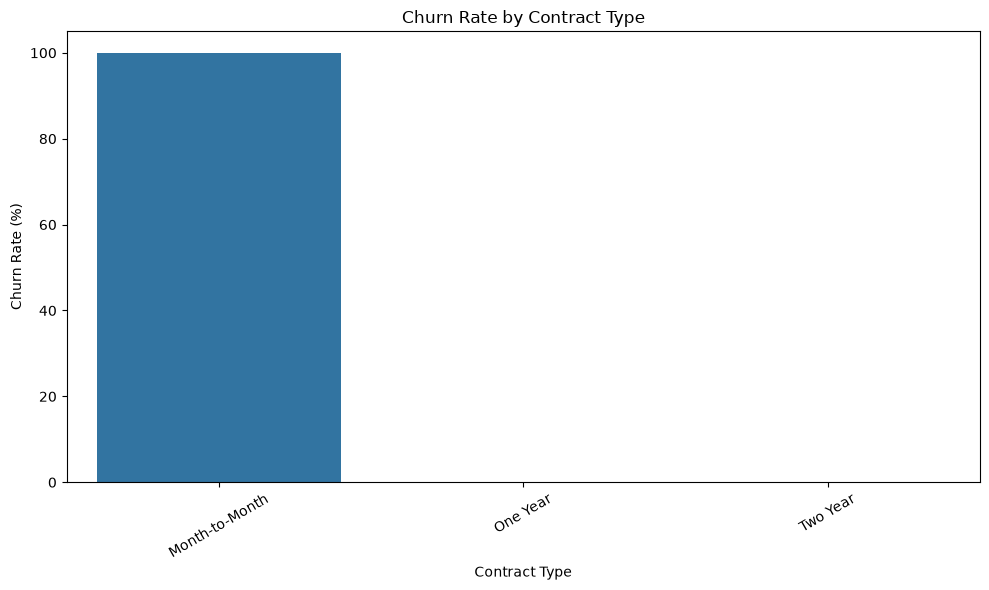

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=contract_churn,
    x="ContractType",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 13. Churn Analysis by Payment Method

Payment method may influence customer retention because different
payment methods can have different levels of convenience and friction.

We calculate churn rate for each payment method.

In [15]:
payment_churn = (
    df_clean.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
    .sort_values("ChurnRate", ascending=False)
)

display(payment_churn)

,PaymentMethod,ChurnRate
2,Debit Card,100.00
3,UPI,75.00
1,Credit Card,33.33
0,Bank Transfer,0.00


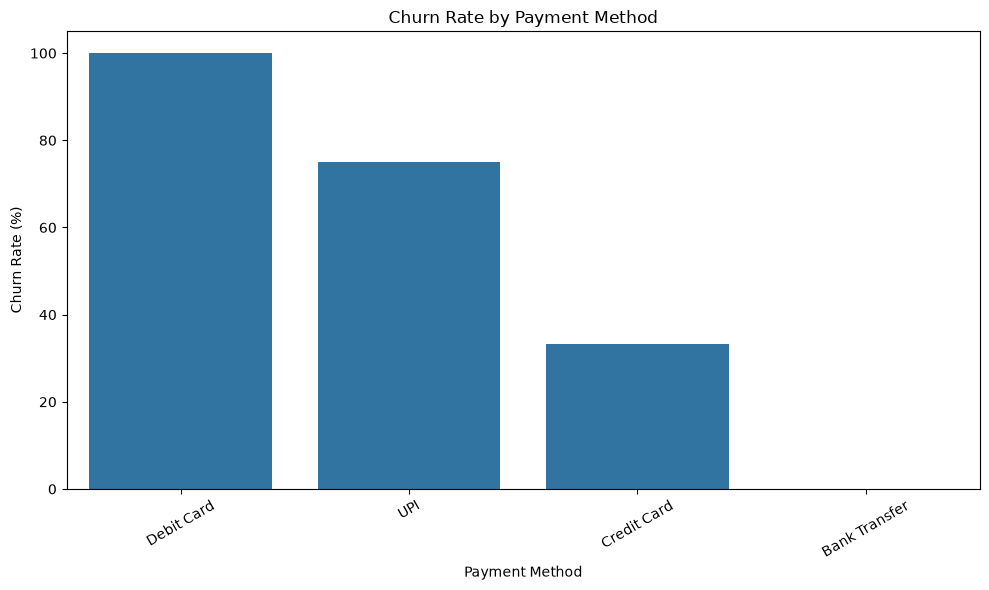

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 14. Churn Analysis by Customer Tenure

Customer tenure indicates how long a customer has remained subscribed.

Customers are grouped into:

- 0–6 months
- 7–12 months
- 13–24 months
- 25+ months

This helps identify whether early-stage customers are more likely to churn.

In [18]:
bins = [0, 6, 12, 24, np.inf]
labels = ["0-6 Months", "7-12 Months", "13-24 Months", "25+ Months"]

df_clean["TenureGroup"] = pd.cut(
    df_clean["TenureMonths"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_churn = (
    df_clean.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(tenure_churn)

,TenureGroup,ChurnRate
0,0-6 Months,100.00
1,7-12 Months,100.00
2,13-24 Months,20.00
3,25+ Months,0.00


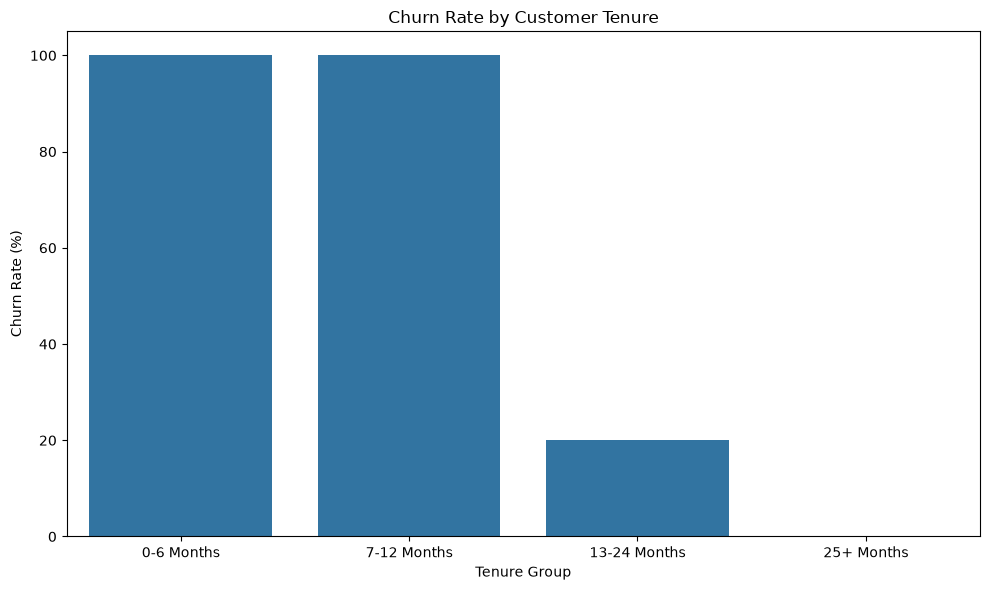

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## 15. Support Tickets and Customer Churn

Frequent support requests may indicate customer dissatisfaction,
product problems, or service issues.

We compare the average number of support tickets between churned
and retained customers.

In [20]:
support_analysis = (
    df_clean.groupby("Churn")["SupportTickets"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(support_analysis)

,Churn,count,mean,median
0,No,8,1.00,1.00
1,Yes,7,4.29,4.00


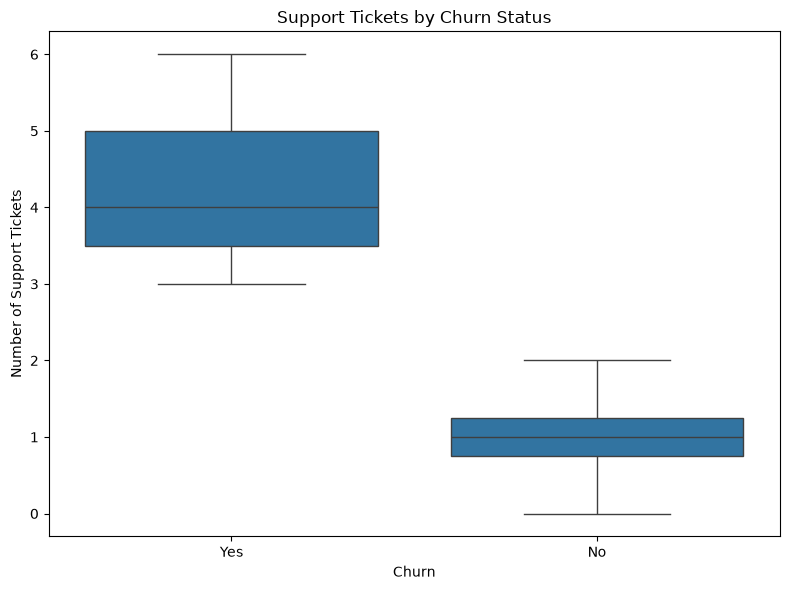

In [21]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="SupportTickets"
)

plt.title("Support Tickets by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Number of Support Tickets")
plt.tight_layout()
plt.show()

## 16. Monthly Charges and Churn

Customers with higher monthly charges may have different churn
behavior than customers with lower monthly charges.

A boxplot is used to compare the distribution of monthly charges
between churned and retained customers.

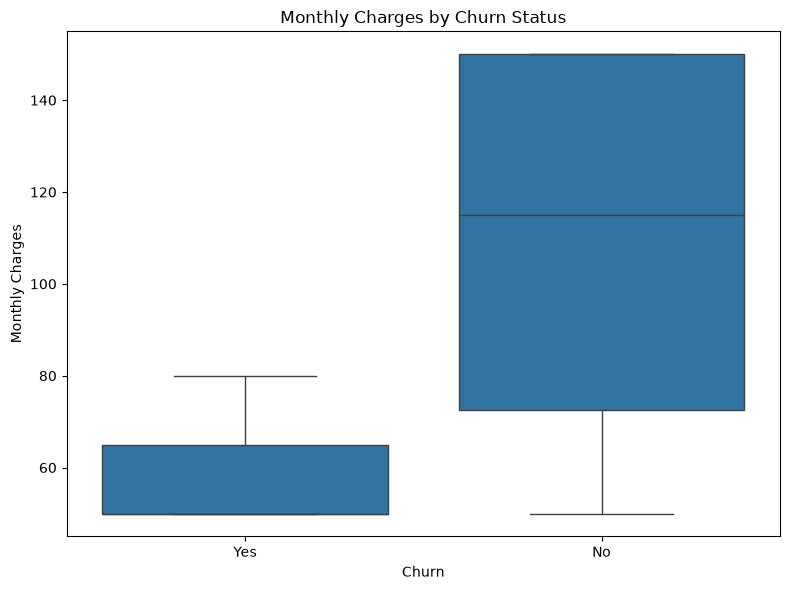

In [22]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

## 17. Churn Distribution

We visualize the number of customers who churned versus those who
remained subscribed.

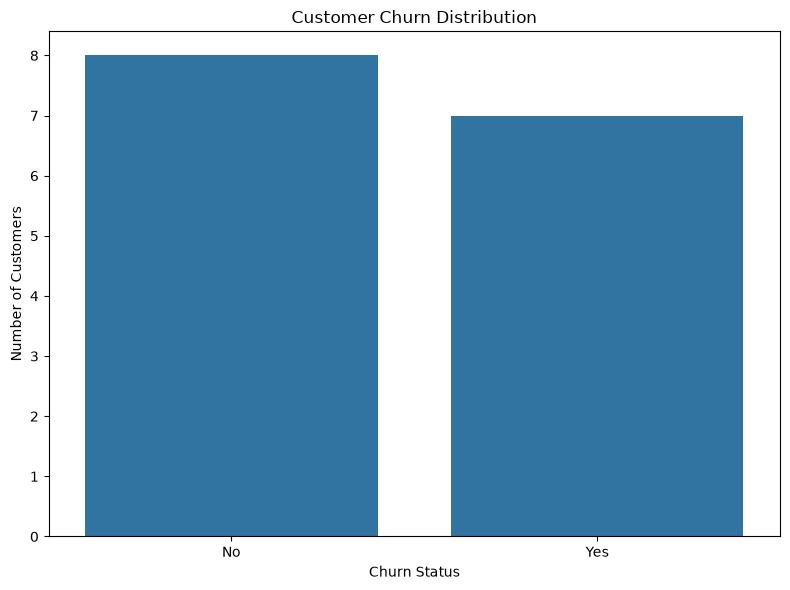

In [23]:
churn_counts = df_clean["Churn"].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 18. Correlation Analysis

A correlation heatmap is used to examine relationships between
numeric variables such as:

- Age
- Tenure
- Monthly Charges
- Total Charges
- Support Tickets
- Observed CLV

Correlation does not prove causation; it only indicates the strength
and direction of linear relationships.

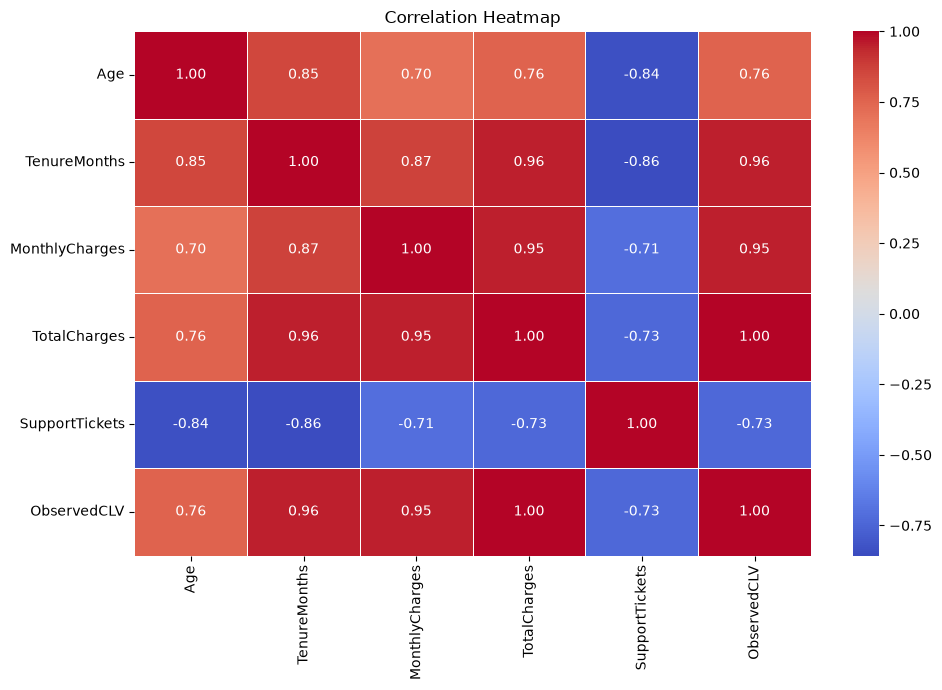

In [24]:
numeric_df = df_clean[
    [
        "Age",
        "TenureMonths",
        "MonthlyCharges",
        "TotalCharges",
        "SupportTickets",
        "ObservedCLV"
    ]
]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 19. Key Business Metrics

The following metrics provide a high-level summary of customer retention
and revenue risk.

In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate",
        "Total MRR",
        "MRR Loss from Churn",
        "MRR Loss Percentage",
        "Average Observed CLV"
    ],
    "Value": [
        total_customers,
        churned_customers,
        total_customers - churned_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        f"₹{total_mrr:,.2f}",
        f"₹{mrr_loss:,.2f}",
        f"{mrr_loss_percentage:.2f}%",
        f"₹{average_clv:,.2f}"
    ]
})

display(summary)

,Metric,Value
0,Total Customers,15
1,Churned Customers,7
2,Retained Customers,8
3,Churn Rate,46.67%
4,Retention Rate,53.33%
5,Total MRR,"₹1,269.85"
6,MRR Loss from Churn,₹409.93
7,MRR Loss Percentage,32.28%
8,Average Observed CLV,"₹2,088.48"


## 20. High-Risk Customer Segments

We identify the contract type and payment method with the highest
observed churn rate in the dataset.

Because this is a small sample dataset, these results should be treated
as directional rather than statistically conclusive.

In [26]:
highest_contract = contract_churn.iloc[0]
highest_payment = payment_churn.iloc[0]
highest_tenure = tenure_churn.sort_values(
    "ChurnRate",
    ascending=False
).iloc[0]

print(
    f"Highest churn contract type: "
    f"{highest_contract['ContractType']} "
    f"({highest_contract['ChurnRate']:.2f}%)"
)

print(
    f"Highest churn payment method: "
    f"{highest_payment['PaymentMethod']} "
    f"({highest_payment['ChurnRate']:.2f}%)"
)

print(
    f"Highest churn tenure group: "
    f"{highest_tenure['TenureGroup']} "
    f"({highest_tenure['ChurnRate']:.2f}%)"
)

Highest churn contract type: Month-to-Month (100.00%)
Highest churn payment method: Debit Card (100.00%)
Highest churn tenure group: 0-6 Months (100.00%)


## 21. Business Recommendations

Based on the observed patterns, recommendations should focus on
the customer segments with comparatively high churn.

However, because the sample contains only a small number of customers,
these findings should be validated using a larger customer dataset
before making major business decisions.

In [27]:
print("BUSINESS RECOMMENDATIONS")
print("-" * 50)

print(
    "1. Focus retention campaigns on the contract segment "
    "with the highest observed churn rate."
)

print(
    "2. Investigate payment methods associated with higher churn "
    "and reduce payment-related friction."
)

print(
    "3. Give additional attention to early-tenure customers "
    "through onboarding and engagement programs."
)

print(
    "4. Monitor customers with frequent support tickets because "
    "high support activity may indicate dissatisfaction."
)

print(
    "5. Consider targeted retention offers for customers with "
    "high monthly revenue exposure."
)

print(
    "6. Repeat the analysis on a larger dataset before implementing "
    "company-wide retention policies."
)

BUSINESS RECOMMENDATIONS
--------------------------------------------------
1. Focus retention campaigns on the contract segment with the highest observed churn rate.
2. Investigate payment methods associated with higher churn and reduce payment-related friction.
3. Give additional attention to early-tenure customers through onboarding and engagement programs.
4. Monitor customers with frequent support tickets because high support activity may indicate dissatisfaction.
5. Consider targeted retention offers for customers with high monthly revenue exposure.
6. Repeat the analysis on a larger dataset before implementing company-wide retention policies.


print("BUSINESS RECOMMENDATIONS")
print("-" * 50)

print(
    "1. Focus retention campaigns on the contract segment "
    "with the highest observed churn rate."
)

print(
    "2. Investigate payment methods associated with higher churn "
    "and reduce payment-related friction."
)

print(
    "3. Give additional attention to early-tenure customers "
    "through onboarding and engagement programs."
)

print(
    "4. Monitor customers with frequent support tickets because "
    "high support activity may indicate dissatisfaction."
)

print(
    "5. Consider targeted retention offers for customers with "
    "high monthly revenue exposure."
)

print(
    "6. Repeat the analysis on a larger dataset before implementing "
    "company-wide retention policies."
)

## 23. Export Analysis Results

The cleaned dataset and summary metrics are exported so they can be
used in the final project report.

In [29]:
# Export cleaned data
df_clean.to_csv(
    "customer_churn_cleaned.csv",
    index=False
)

# Export summary metrics
summary.to_csv(
    "customer_churn_summary.csv",
    index=False
)

# Export churn analysis tables
contract_churn.to_csv(
    "churn_by_contract.csv",
    index=False
)

payment_churn.to_csv(
    "churn_by_payment_method.csv",
    index=False
)

tenure_churn.to_csv(
    "churn_by_tenure.csv",
    index=False
)

print("All analysis files exported successfully.")

All analysis files exported successfully.
